# generalisation test
- testing models generated on C4 (discovery) on ybt

In [7]:
# load libraries and data 
import pandas as pd
import joblib
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score

# load ybt processed data
ybt_df = pd.read_csv('/Users/eb2007/playground/bullpy/c4_play2/data/processed/YBT_processed.csv')
print("YBT data shape:", ybt_df.shape)

YBT data shape: (24205, 61)


In [8]:
# load trained model 
model = joblib.load('/Users/eb2007/playground/bullpy/c4_play2/models/logreg_rf.joblib')  # or logreg_xgb.joblib
print("model loaded:", type(model))

model loaded: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [9]:
# align features 
# get feature list ised by model 
feature_list = model.feature_names_in_

# check for missing features 
missing_features = [f for f in feature_list if f not in ybt_df.columns]

# select features for prediction 
X_ybt = ybt_df[feature_list]
y_true = ybt_df['autism_target']
print("Feature matrix shape:", X_ybt.shape)

print("Missing features in YBT data:", missing_features)

Feature matrix shape: (24205, 20)
Missing features in YBT data: []


In [10]:
# predict and evaluate 

# predict 
y_pred = model.predict(X_ybt)
if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X_ybt)[:, 1]
else:
    y_proba = None

# evaluation 
print("classification report:")
print(classification_report(y_true, y_pred))
print("confusion matrix:")
print(confusion_matrix(y_true, y_pred))
if y_proba is not None:
    print("roc auc score:", roc_auc_score(y_true, y_proba))

classification report:
              precision    recall  f1-score   support

           0       0.90      0.01      0.03     23447
           1       0.03      0.96      0.06       758

    accuracy                           0.04     24205
   macro avg       0.47      0.48      0.04     24205
weighted avg       0.87      0.04      0.03     24205

confusion matrix:
[[  303 23144]
 [   33   725]]
roc auc score: 0.3251468843502997


In [11]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load the XGBoost model
xgb_model = joblib.load('/Users/eb2007/playground/bullpy/c4_play2/models/logreg_xgb.joblib')

# Get the feature list
xgb_feature_list = xgb_model.feature_names_in_

# Check for missing features
missing_features = [f for f in xgb_feature_list if f not in ybt_df.columns]
print("Missing features in YBT data:", missing_features)

# Select features for prediction
X_ybt_xgb = ybt_df[xgb_feature_list]
y_true = ybt_df['autism_target']

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_ybt_xgb)
if hasattr(xgb_model, "predict_proba"):
    y_proba_xgb = xgb_model.predict_proba(X_ybt_xgb)[:, 1]
else:
    y_proba_xgb = None

print("classification report:")
print(classification_report(y_true, y_pred_xgb))
print("confusion matrix:")
print(confusion_matrix(y_true, y_pred_xgb))
if y_proba_xgb is not None:
    print("roc auc score:", roc_auc_score(y_true, y_proba_xgb))

Missing features in YBT data: []
classification report:
              precision    recall  f1-score   support

           0       0.77      0.01      0.02     23447
           1       0.03      0.93      0.06       758

    accuracy                           0.04     24205
   macro avg       0.40      0.47      0.04     24205
weighted avg       0.75      0.04      0.02     24205

confusion matrix:
[[  180 23267]
 [   54   704]]
roc auc score: 0.2721234653397271


# Further investigation 

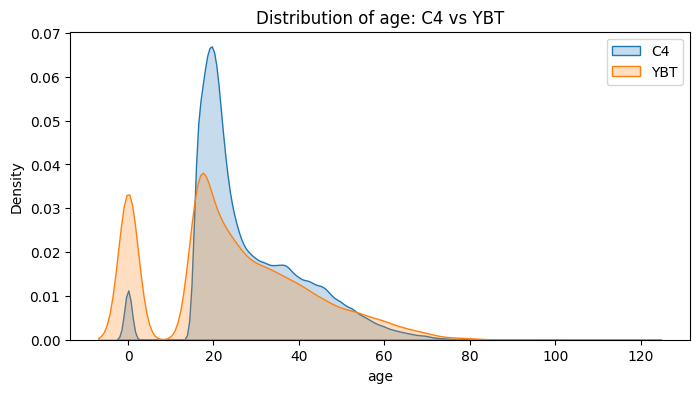

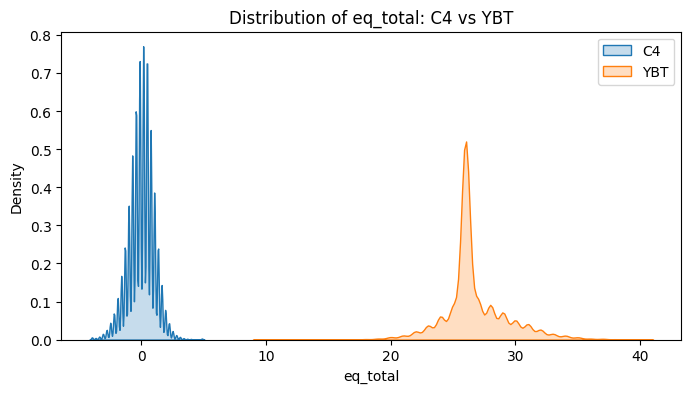

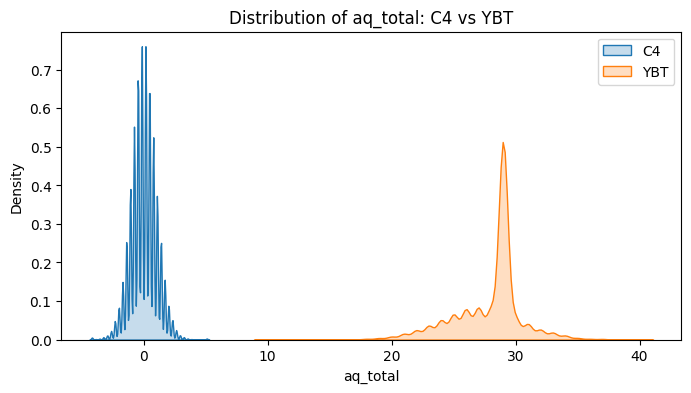

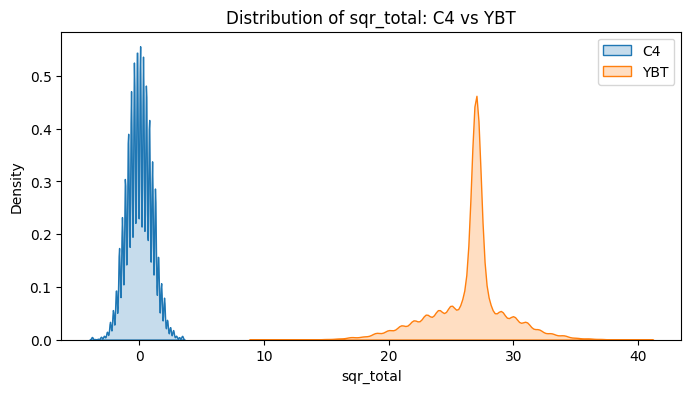

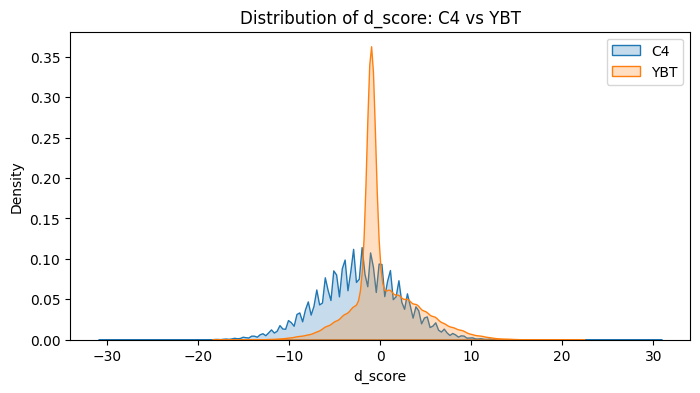

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load c4 processed data 
c4_df = pd.read_csv('/Users/eb2007/playground/bullpy/c4_play2/data/processed/data_c4_processed.csv')

# list of key features to compare
features_to_compare = ['age', 'eq_total', 'aq_total', 'sqr_total', 'd_score']

for feat in features_to_compare:
    plt.figure(figsize=(8,4))
    sns.kdeplot(c4_df[feat], label='C4', fill=True)
    sns.kdeplot(ybt_df[feat], label='YBT', fill=True)
    plt.title(f'Distribution of {feat}: C4 vs YBT')
    plt.legend()
    plt.show()

In [13]:
# compare target prevalence
print("C4 autism prevalence:", c4_df['autism_target'].mean())
print("YBT autism prevalence:", ybt_df['autism_target'].mean())

C4 autism prevalence: 0.059650731781879324
YBT autism prevalence: 0.03131584383391861


In [14]:
# compare feature emans by group
print("C4 group means:")
print(c4_df.groupby('autism_target').mean(numeric_only=True)[features_to_compare])
print("YBT group means:")
print(ybt_df.groupby('autism_target').mean(numeric_only=True)[features_to_compare])

C4 group means:
                     age  eq_total  aq_total  sqr_total   d_score
autism_target                                                    
0              28.714634  0.008709 -0.008135   0.021198 -2.328810
1              23.264243 -0.137291  0.128235  -0.334175 -1.350129
YBT group means:
                     age   eq_total   aq_total  sqr_total   d_score
autism_target                                                      
0              24.612701  26.696678  27.964089  26.478355  0.218322
1              28.684697  27.176781  25.675462  27.081794  0.094987


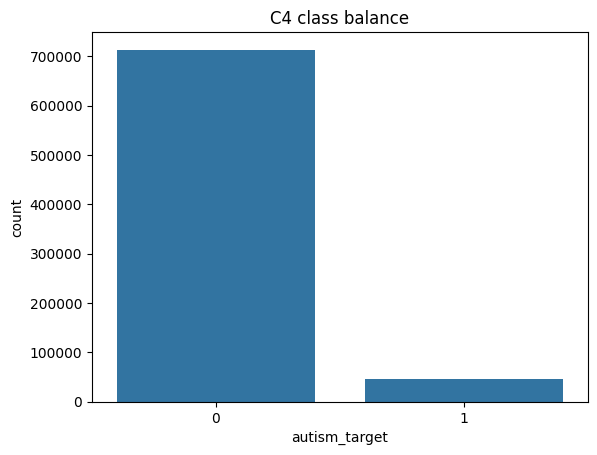

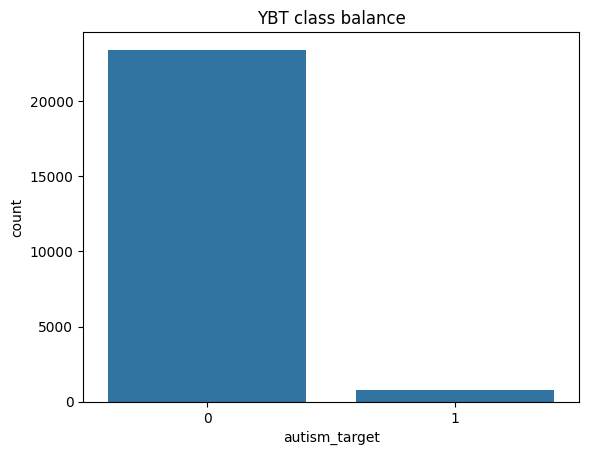

In [15]:
# visualise class balance 
sns.countplot(x='autism_target', data=c4_df)
plt.title('C4 class balance')
plt.show()

sns.countplot(x='autism_target', data=ybt_df)
plt.title('YBT class balance')
plt.show()

In [18]:
# explore feature importances 
importances = model.feature_importances_
feature_names = model.feature_names_in_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(10))

age_x_aq     0.111350
age          0.091669
spq_total    0.084603
sqr_total    0.070262
d_score      0.069499
aq_total     0.060386
eq_total     0.050414
sex_x_eq     0.050391
aq_5         0.041579
aq_8         0.039625
dtype: float64
